<a href="https://colab.research.google.com/github/gerardocortes3/quant-trend-backtester/blob/main/Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance pandas matplotlib


/tmp/ipykernel_2366/37726265.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed

Fetching data for TSLA...

--- TSLA Risk Analysis Summary ---
Current Price (End of Period): $435.79
Most Recent Annualized Volatility: 36.72%
Maximum Historical Drawdown: -53.77%


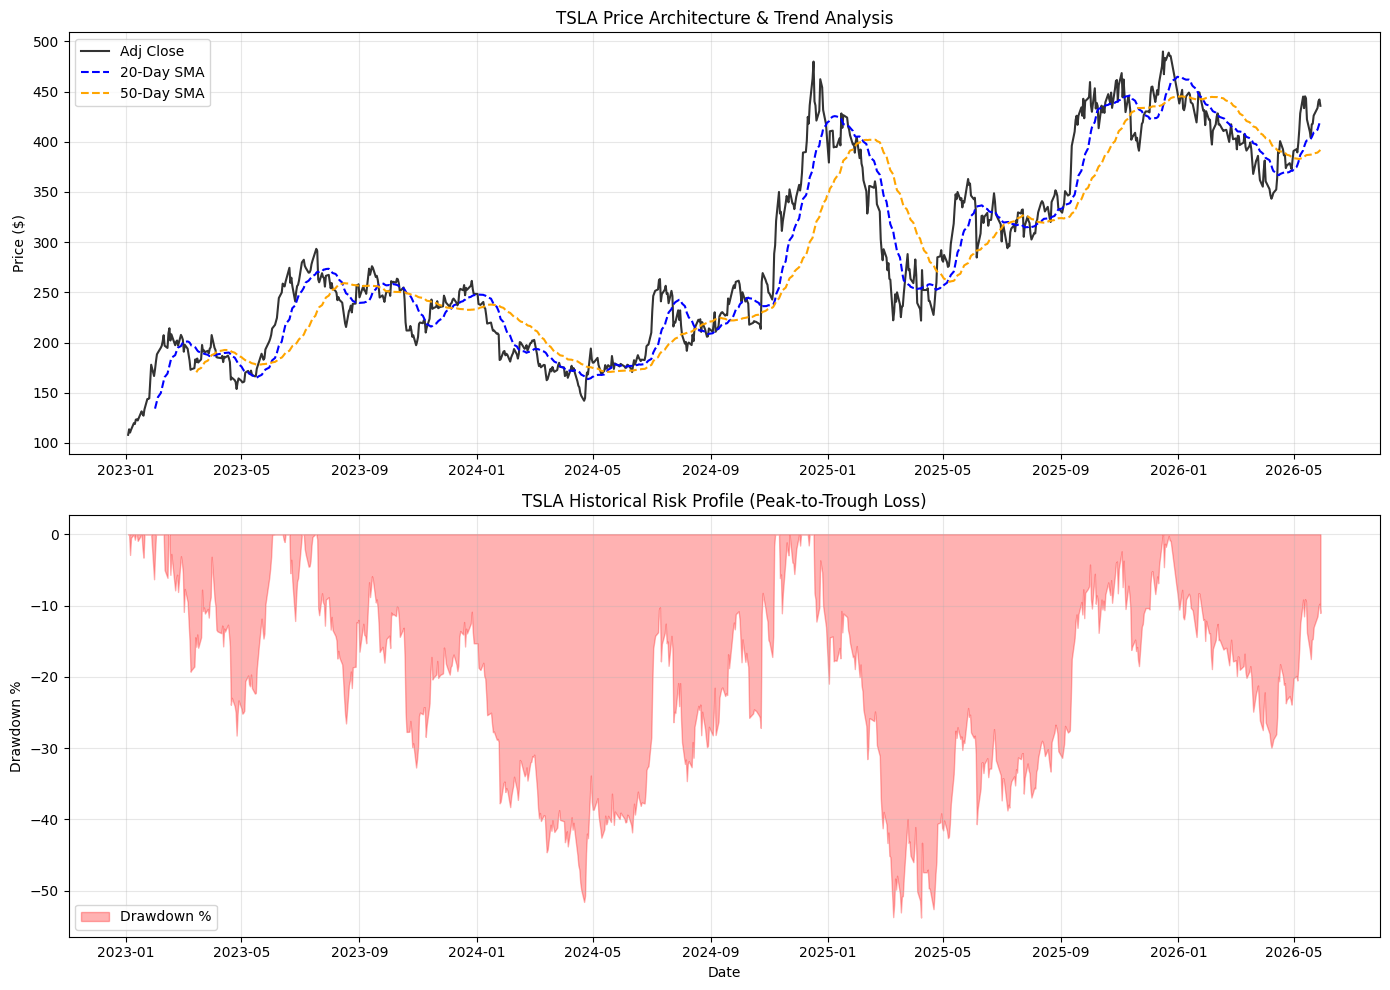

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetch historical market data from the API
ticker = "TSLA"
print(f"Fetching data for {ticker}...")
data = yf.download(ticker, start="2023-01-01", end="2026-06-01")

# Clean up data framing if multi-index headers occur
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Keep only the adjusted close price for calculations
df = data[['Close']].copy()

# 2. Trend Metrics: Calculate 20-day and 50-day Simple Moving Averages
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

# 3. Risk Metrics: Calculate Rolling Volatility (annualized)
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility_30D'] = df['Daily_Return'].rolling(window=30).std() * (252 ** 0.5)

# 4. Maximum Drawdown: Track the worst peak-to-trough drop
df['Peak'] = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - df['Peak']) / df['Peak']
max_drawdown = df['Drawdown'].min()

print(f"\n--- {ticker} Risk Analysis Summary ---")
print(f"Current Price (End of Period): ${df['Close'].iloc[-1]:.2f}")
print(f"Most Recent Annualized Volatility: {df['Volatility_30D'].iloc[-1]*100:.2f}%")
print(f"Maximum Historical Drawdown: {max_drawdown*100:.2f}%")

# 5. Data Visualization
plt.figure(figsize=(14, 10))

# Plot 1: Price and Trend Lines
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Adj Close', color='black', alpha=0.8)
plt.plot(df.index, df['SMA20'], label='20-Day SMA', color='blue', linestyle='--')
plt.plot(df.index, df['SMA50'], label='50-Day SMA', color='orange', linestyle='--')
plt.title(f"{ticker} Price Architecture & Trend Analysis")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Historical Drawdown Profile
plt.subplot(2, 1, 2)
plt.fill_between(df.index, df['Drawdown'] * 100, 0, color='red', alpha=0.3, label='Drawdown %')
plt.title(f"{ticker} Historical Risk Profile (Peak-to-Trough Loss)")
plt.xlabel("Date")
plt.ylabel("Drawdown %")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Fetching data for SPY...


/tmp/ipykernel_2366/1590889413.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed



--- SPY Risk Analysis Summary ---
Current Price (End of Period): $756.48
Most Recent Annualized Volatility: 10.02%
Maximum Historical Drawdown: -18.76%


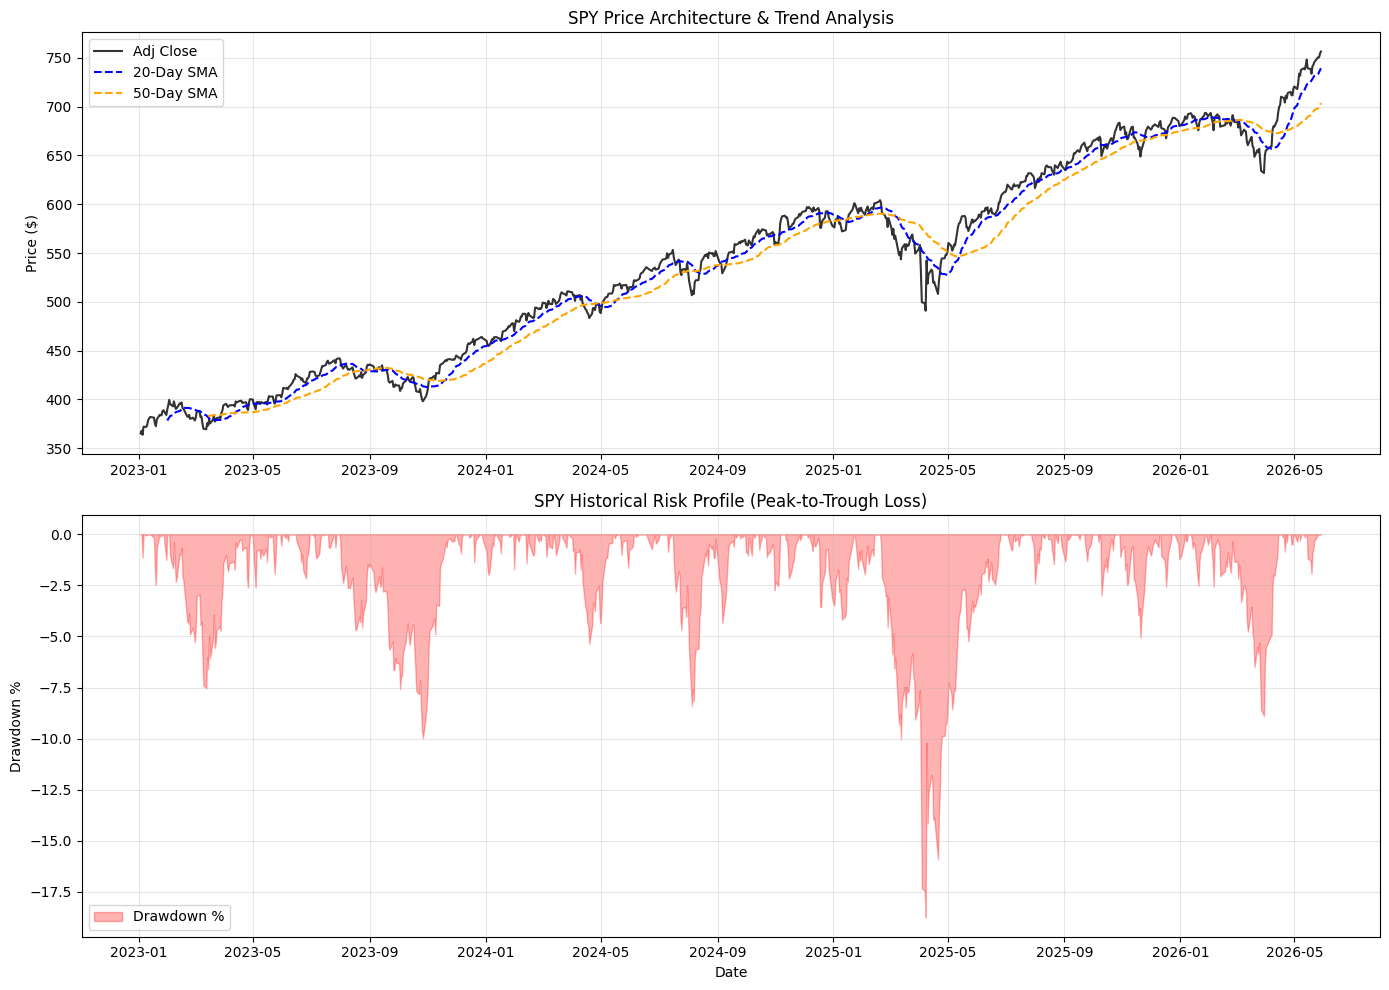

In [ ]:
# 1. Fetch historical market data from the API
ticker = "SPY"
print(f"Fetching data for {ticker}...")
data = yf.download(ticker, start="2023-01-01", end="2026-06-01")

# Clean up data framing if multi-index headers occur
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Keep only the adjusted close price for calculations
df = data[['Close']].copy()

# 2. Trend Metrics: Calculate 20-day and 50-day Simple Moving Averages
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

# 3. Risk Metrics: Calculate Rolling Volatility (annualized)
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility_30D'] = df['Daily_Return'].rolling(window=30).std() * (252 ** 0.5)

# 4. Maximum Drawdown: Track the worst peak-to-trough drop
df['Peak'] = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - df['Peak']) / df['Peak']
max_drawdown = df['Drawdown'].min()

print(f"\n--- {ticker} Risk Analysis Summary ---")
print(f"Current Price (End of Period): ${df['Close'].iloc[-1]:.2f}")
print(f"Most Recent Annualized Volatility: {df['Volatility_30D'].iloc[-1]*100:.2f}%")
print(f"Maximum Historical Drawdown: {max_drawdown*100:.2f}%")

# 5. Data Visualization
plt.figure(figsize=(14, 10))

# Plot 1: Price and Trend Lines
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Adj Close', color='black', alpha=0.8)
plt.plot(df.index, df['SMA20'], label='20-Day SMA', color='blue', linestyle='--')
plt.plot(df.index, df['SMA50'], label='50-Day SMA', color='orange', linestyle='--')
plt.title(f"{ticker} Price Architecture & Trend Analysis")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Historical Drawdown Profile
plt.subplot(2, 1, 2)
plt.fill_between(df.index, df['Drawdown'] * 100, 0, color='red', alpha=0.3, label='Drawdown %')
plt.title(f"{ticker} Historical Risk Profile (Peak-to-Trough Loss)")
plt.xlabel("Date")
plt.ylabel("Drawdown %")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()